## Example of calibration for simple time series model
Based on "Sequentially valid tests for forecast calibration"  
By: 
Sebastian Arnold
Alexander Henzi
Johanna F. Ziegel

Background:

Econometric forecasts are typically presented as point estimates $\hat{y}_{t+h}$ and evaluated using loss functions like $L(y_{t+h},\hat{y}_{t+h})$, for example mean squared error (MSE). However, each prediction represents a parameter of the underlying distribution, not just a single value. For example, in an AR(1) model with normal errors, the forecast describes the conditional mean where $y_t|y_{t-1} \sim \mathcal{N}(\theta y_{t-1},\sigma^2)$. Probabilistic forecasts incorporate uncertainty about $\hat{y}_{t+h}$ through forecasting a probability distributions rather than point estimates alone.

This notebook extents the notion of loss functions $L(y_{t+h},\hat{y}_{t+h})$ to probabilistic forecast. The concept of checking whether probalistic forecast are "good" is what is know as calibration.

In [23]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

Consider a true data generating process to be an AR(1), it can for instance represent a true change in sales, denoted as $(y_t)_{t\in\mathbb{N}}$. Additionally, assume that stationary conditions hold. For each simulated value, the true process is given by:
\begin{equation*}
    Y:=y_t|y_{t-1} \sim \mathcal{N}(\theta y_{t-1},\sigma^2).
\end{equation*}
where $\theta$ is the true parameters that describes the true relationship between $y_t$ and $y_{t-1}$. In practice $\theta$ is unknown and must be estimated by historical data yielding the fitted distribution:
\begin{equation*}
    F := y_t|y_{t-1} \sim \mathcal{N}(\hat{\theta}y_{t-1},\sigma^2).
\end{equation*}
Now to illustrate the effect of miscalibrated forecast consider that the fitted/forecasted distribution $F$ is transformed according to $F = \mathcal{N}(\hat{\theta}y_{t-1} + \epsilon,(\sigma+ \delta)^2)$, where $\epsilon,\delta \in \{-0.5,-0.3, \cdots, 0.5\}$ are the bias and dispersion, respectively and $\hat{\theta}$ the maximum likelihood estimator. This transformation would result in probabilistic forecasts being misaligned with the true data process. Only for the case of $\epsilon=\delta=0$ and $\hat{\theta} = \theta$ are the probabilistic forecast perfectly calibrated.


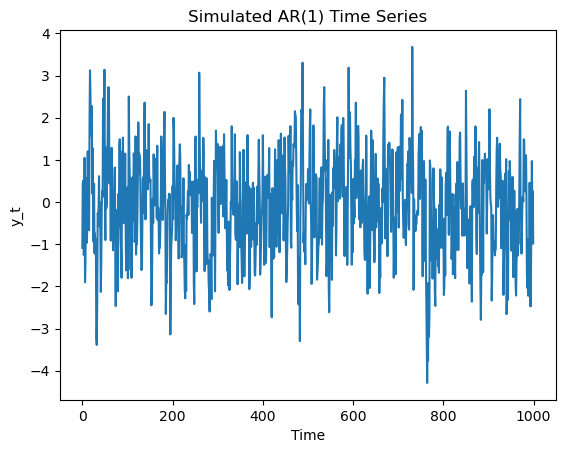

In [24]:
# --- Example 1: Simulate an AR(1) time series ---
np.random.seed(123)
n = 1000

# --- Generate AR(1) series y_t = 0.5 y_{t-1} + eps_t ---
sd0 = 1
eps = np.random.normal(0, sd0, n)

y = np.zeros(n)
y[0] = eps[0]
for t in range(1, n):
    y[t] = 0.5 * y[t - 1] + eps[t]

plt.plot(np.arange(n), y)
plt.title("Simulated AR(1) Time Series")
plt.xlabel("Time")
plt.ylabel("y_t")
plt.show()


In [25]:
# --- Construct lagged dataframe ---
Y_true = pd.DataFrame({
    "y": y[1:],          # current value
    "y1": y[:-1]         # lag 1
})

# --- OLS: y ~ y1 - 1 (no intercept) ---
model = sm.OLS(Y_true["y"], Y_true["y1"])
results = model.fit()
Y_fitted = results.fittedvalues.values

# --- Bias & dispersion grid --- 
# This is induced distance between the true parameter value and the estimated one. 
# Where bias is the error in the mean estimate, dispersion is the error in the variance estimate.
# Note  that for a AR(1) process the dispersion is not estimated.
bias_vals = [-0.5, -0.3, -0.1, 0, 0.1, 0.3, 0.5]
disp_vals = [-0.5, -0.3, -0.1, 0, 0.1, 0.3, 0.5]

bias_disp = pd.DataFrame(
    [(b, d) for b in bias_vals for d in disp_vals],
    columns=["bias", "dispersion"]
)

# Maximimun likelihood estimation of theta parameter
model.fit().params

y1    0.523706
dtype: float64

Testing for misalignment can be done by the use of the Probability Integral transform theorem. Recall (theorem 2.1.10 in Casella and Berger), a simple proof of this theorem can also be found in Casella and Berger ~p.55.

*Theorem* : Let $X$ have continuous cdf $F_X(x)$ and define the random variable $Y = F_X(X)$. Then $Y$ is uniformly distributed on (0, 1), that is, $P(Y ≤ y) = y$.  

Translating this theorem to the AR(1) example one would obtain the following expression. The probability integral transform of a forecast $F$ for a random variable $Y$ is defined by:
\begin{equation*}
    Z_F(Y) = F(Y). 
\end{equation*}
The forecast $F$ is probabilistically well calibrated if $Z_F(Y)~\sim \mathcal{U}(0,1)$, where realization of this distribution are referred to as pit values $(z_t)_{t\in\mathbb{N}}$. One can now construct a hypothesis test for testing whether a probabilistic forecast $F$ is calibrated by considering:

\begin{equation*}
    \mathcal{H}_0: Z_F(Y) \sim \mathcal{U}(0,1) \quad vs \quad \mathcal{H}_1: Z_F(Y) \in \mathcal{D}([0,1])
\end{equation*}
where $\mathcal{D}([0,1])$ is the family of valid distributions on $[0,1]$ excluding the uniform distribution. 

Rather then going directly to constructing parametric and non-parametric test we continue to illustrate the effect of miscalibrated forecast with $F = \mathcal{N}(\hat{\theta}y_{t-1} + \epsilon,(\sigma+ \delta)^2)$.


In [ ]:
# --- Compute PIT values ---
rows = []
for _, row in bias_disp.iterrows():
    eps = row["bias"]
    delta = row["dispersion"]
    
    # Apply the probability integral transform (PIT)
    # Note that norm.cdf is the cdf of the probabilistic forecast F.
    # Hence the following line computes Z_F(Y) with F = N(Y_fitted + eps, (1 + delta)^2)
    pit = norm.cdf(
        Y_true["y"], 
        loc=Y_fitted + eps, # Y_fitted := theta_hat * y_{t-1}
        scale=np.sqrt(1 + delta) # Note that in norm.cdf scale is stddev not variance
    )
    
    df_tmp = pd.DataFrame({
        "bias": eps,
        "dispersion": delta,
        "pit": pit
    })
    rows.append(df_tmp)

hist_dat = pd.concat(rows, ignore_index=True)


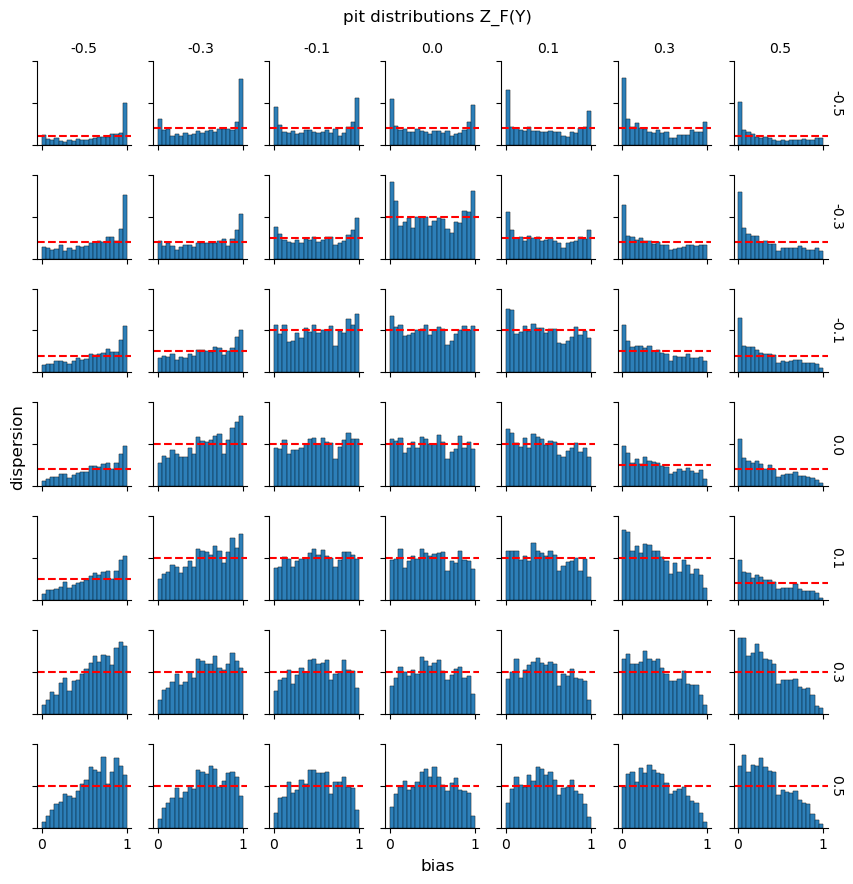

In [26]:
g = sns.FacetGrid(
    hist_dat, 
    row="dispersion", 
    col="bias", 
    sharey=False,
    margin_titles=True,
    height=1.2
)

g.map_dataframe(
    sns.histplot, 
    x="pit", 
    stat="density", 
    binwidth=0.05, 
   binrange=(0,1)
)

g.map_dataframe(
    sns.histplot, 
    x="pit", 
    stat="density", 
    binwidth=0.05, 
    binrange=(0,1)
)
g.refline(y=1, color="red", linestyle="--")
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.set_axis_labels("", "")
g.set_yticklabels([])
g.tight_layout()
g.figure.text(0.5,0, "bias", ha="center", va="center", fontsize=12)
g.figure.text(0, 0.5, "dispersion", ha="center", va="center", rotation="vertical", fontsize=12)
g.figure.suptitle(t=r"pit distributions Z_F(Y)", y= 1.02, fontsize=12)
plt.show()

It becomes clear from this example that if the probabilistic forecast is misaligned the corresponding distribution $Z_F(Y)$ will diverge from following a standard uniform distribution. 

## Using e-values to test miscalibration
Under development: here will come an example of both the parametric and non-parametric setting 